In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud




In [5]:

df = pd.read_csv("twitter_training.csv.zip")
df.columns = ["id", "entity", "sentiment", "text"]
df.dropna(inplace=True)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17732\3157014557.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, palette="Set2")


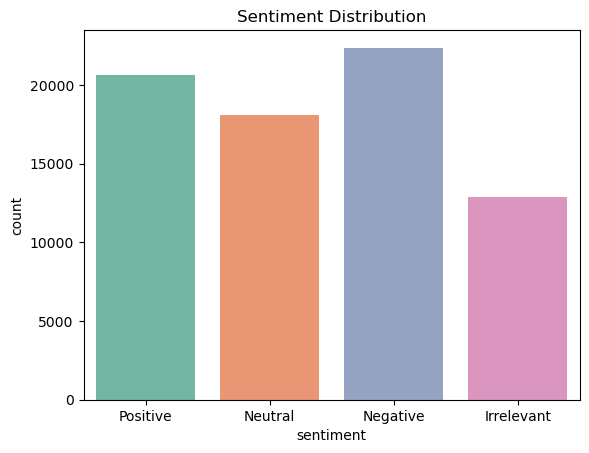

In [6]:


sns.countplot(x="sentiment", data=df, palette="Set2")
plt.title("Sentiment Distribution")
plt.show()


In [7]:

X_train, X_test, y_train, y_test = train_test_split(df["text"], df["sentiment"], test_size=0.2, random_state=42)


In [8]:


vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [9]:


model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [10]:

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

  Irrelevant       0.69      0.53      0.60      2624
    Negative       0.74      0.77      0.75      4463
     Neutral       0.70      0.64      0.67      3589
    Positive       0.66      0.77      0.71      4123

    accuracy                           0.70     14799
   macro avg       0.70      0.68      0.68     14799
weighted avg       0.70      0.70      0.69     14799



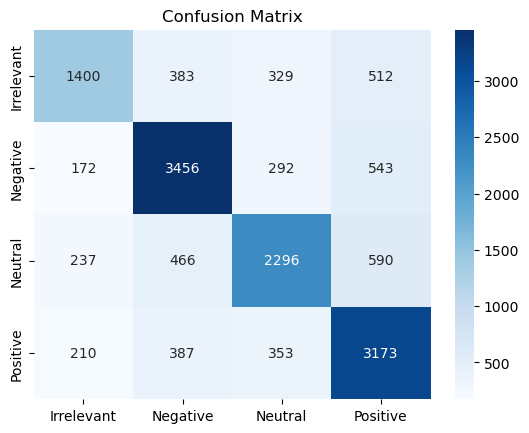

In [11]:

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.show()



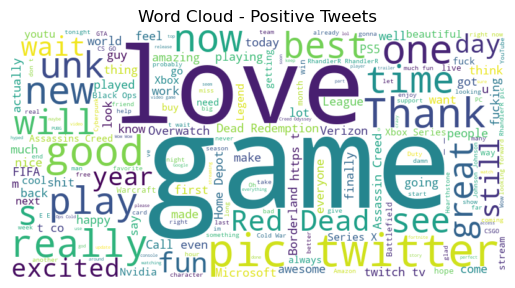

In [13]:

positive_texts = " ".join(df[df['sentiment']=="Positive"]["text"])
wc_pos = WordCloud(width=800, height=400, background_color="white").generate(positive_texts)
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Tweets")
plt.show()



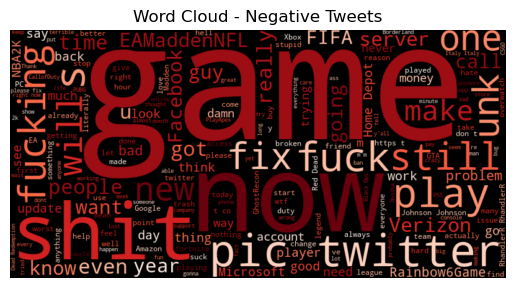

In [14]:
negative_texts = " ".join(df[df['sentiment']=="Negative"]["text"])
wc_neg = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(negative_texts)
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Tweets")
plt.show()